overwritten file


'\n[id,x,y,z]\nself.network_point = []\n    #connection matrix\n    self.matrix_connection = []\n    #distance matrix\n    self.matrix_distance = []       \n    #dictionarry of edge point  (from, to):[id,x,y,z]\n    self.edge_points = dict()\n\n\n'

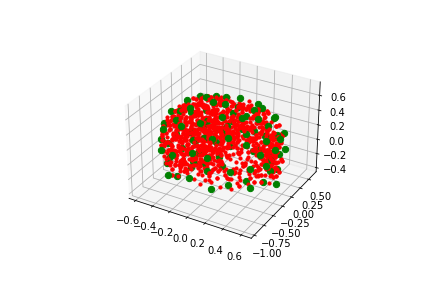

In [160]:
import imp
import network
import my_lammps as ml
import lammps
import logger 

imp.reload(network)
imp.reload(ml)
imp.reload(lammps)
imp.reload(logger)

network = network.Network()

file_path = "/Users/mathieuouellet/Dropbox/My Mac (mathieu’s MacBook Pro)/Desktop/brain_point.txt"


#network.create_random_network( n=15, density_edge = 0.2, edge_point_density = 5, dist_min = 0.5, rand=True)

network.create_network_from_file_RAS(file_path,1000, 8, 3)

network.create_Lammps_file("test_network2.ij", K=2)

network.plot()


#print(*network.network_point, sep="\n")
#print("\n\n")
#print(*network.get_atom_list(), sep="\n")
#print("\n\n")
#print(*network.get_connection(), sep="\n")




"""
[id,x,y,z]
self.network_point = []
    #connection matrix
    self.matrix_connection = []
    #distance matrix
    self.matrix_distance = []       
    #dictionarry of edge point  (from, to):[id,x,y,z]
    self.edge_points = dict()


"""


LAMMPS output is captured by PyLammps wrapper
neigh
pair
nve
logging
setup done


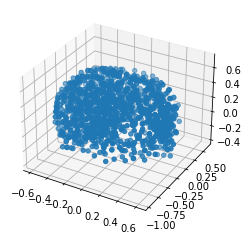

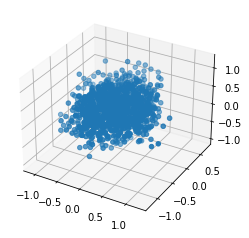

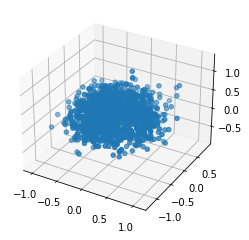

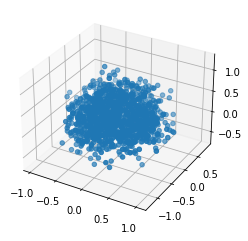

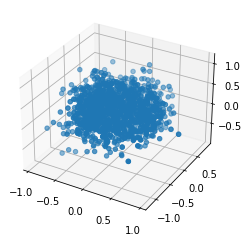

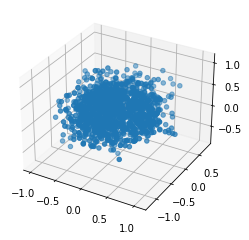

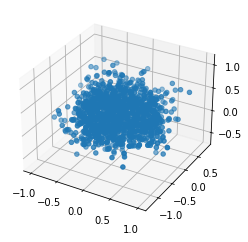

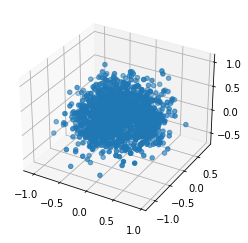

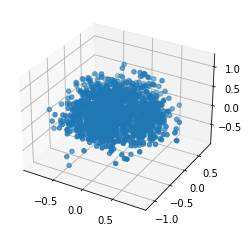

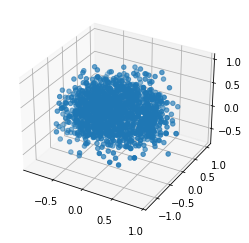

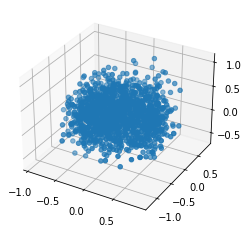

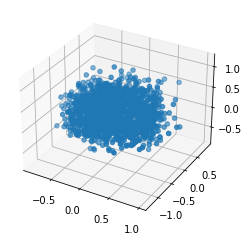

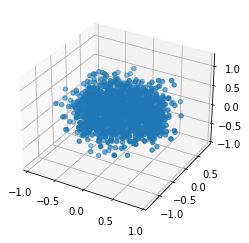

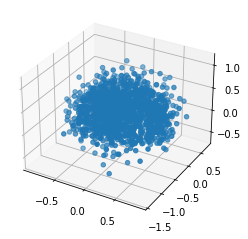

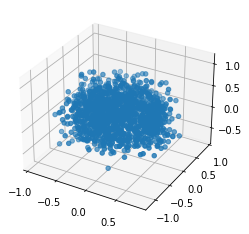

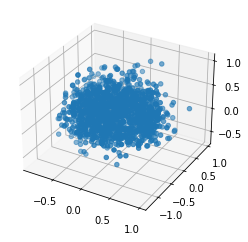

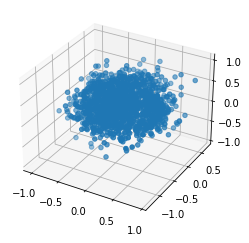

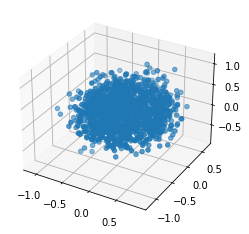

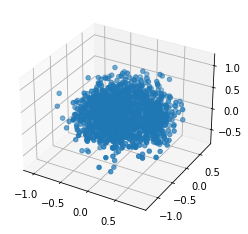

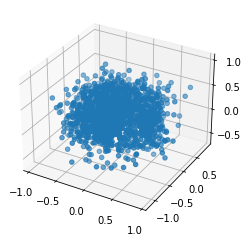

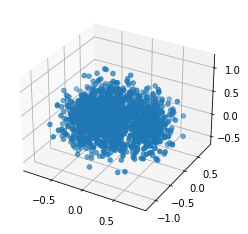

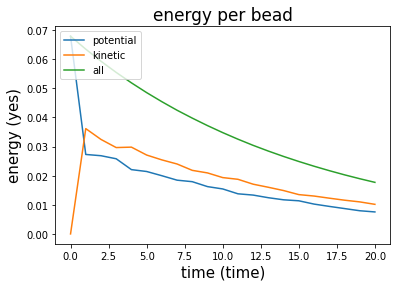

In [161]:
L_main = lammps.PyLammps()
id_counter = ml.ID_counter()
L = ml.MyLammps(L_main,id_counter )

%matplotlib inline

file_path = "test_network2.ij"

step_time = 3
n_step = 10000
seed = 4
n=20



L.L.command("clear")
L.L.command("boundary f f f")


#L.L.command("fix "+str(L.id_counter.next()) +" frette freeze")
#L.L.units("lj")
L.create_molecule_3d(file_path)

#L.L.command("pair_style gauss 12.0")
#L.L.command("pair_coeff * * 0.1 1.0" )

print("neigh")
L.L.command("group edge type 2")
L.L.command("neighbor 1 bin")
print("pair")
L.L.command("pair_style soft 0.1")
L.L.command("pair_coeff 1 1 0.0 0.1" )
L.L.command("pair_coeff 1 2 0.0 0.1" )
L.L.command("pair_coeff 2 2 0.1 0.1" )
L.L.command("fix 100 edge viscous 0.02")

print("nve")
#L.L.command("pair_style lj/cut 2.0")
#L.L.command("pair_coeff * * 0.00000000000000001 1  2.0" )
L.L.command("fix " + str(L.id_counter.next()) + " all   nve")
L.L.command("timestep " + str(step_time/n_step))

print("logging")
main_logger = logger.Logger(L, [], is_2d=False)
main_logger.log(0, is_angle=False)
print("setup done")

for i in range(n):
    L.L.command("thermo " + str(int(n_step)))
    #L.L.command("fix " + str(L.id_counter.next()) + " all langevin "+ str(temp) + " " + str(temp)+ " " + str(damping)+ " " + str(seed))
    L.L.command("run " + str(n_step))
    main_logger.log(i+1, is_angle=False) 
    main_logger.plot_positions( index_list = [i])

#L.L.command("fix " + str(L.id_counter.next()) + " all nvt temp " + str(0.00002) + " " + str(1) + " 1")



main_logger.plot_positions( index_list = [-1])
main_logger.plot_energy()


In [3]:
def set_point(from_pt, to_pt, ind_temp):
        xline = [main_logger.struct_list[0][ind_temp][from_pt],main_logger.struct_list[0][ind_temp][to_pt]] 
        yline = [main_logger.struct_list[1][ind_temp][from_pt],main_logger.struct_list[1][ind_temp][to_pt]]
        zline = [main_logger.struct_list[2][ind_temp][from_pt],main_logger.struct_list[2][ind_temp][to_pt]]
        return xline,yline,zline

In [61]:

import matplotlib.pyplot as plt

def plot_network(ind_temp):

    fig = plt.figure()
    ax = plt.axes(projection='3d')

    for pt in network.network_point:
        ind_pt  = pt[0]
        ax.scatter3D( main_logger.struct_list[0][ind_temp][ind_pt-1],main_logger.struct_list[1][ind_temp][ind_pt-1],main_logger.struct_list[2][ind_temp][ind_pt-1], c='r')

    for key in network.edge_points:
        from_pt = key[1]
        to_pt = key[0]

        for n, pt in enumerate(network.edge_points[key]):
            ind_pt  = pt[0]-1
            if n==0:
                line = set_point(from_pt, ind_pt, ind_temp)
                ax.plot3D(line[0], line[1], line[2], 'gray')
            else:
                ind_next_pt = network.edge_points[key][n-1][0]-1
                line = set_point(ind_pt, ind_next_pt, ind_temp)
                ax.plot3D(line[0], line[1], line[2], 'gray')

        ind_pt  = network.edge_points[key][-1][0]-1
        line = set_point(ind_pt, to_pt, ind_temp)
        ax.plot3D(line[0], line[1], line[2], 'gray')

    plt.show()


In [ ]:
%matplotlib notebook
for i in range(9):
    plot_network(i)

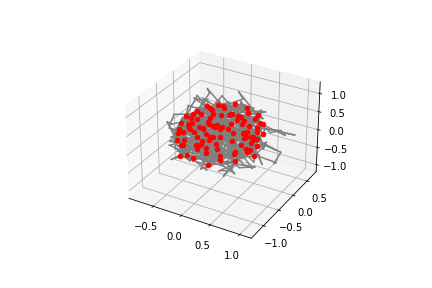

In [158]:
%matplotlib widget
plot_network(17)

In [87]:
def print_blender_network(file_name, ind_temp):

    file1 = open(file_name,"w") 
    for pt in network.network_point:
        ind_pt  = pt[0]
        file1.write(str(ind_pt) + "," + str(pt[1]) + "," + str(pt[2])+ "," + str(pt[3]) + ",1\n" )
        

    for key in network.edge_points:

        for n, pt in enumerate(network.edge_points[key]):
            ind_pt  = pt[0]-1
            x = main_logger.struct_list[0][ind_temp][ind_pt]
            y = main_logger.struct_list[1][ind_temp][ind_pt]
            z = main_logger.struct_list[2][ind_temp][ind_pt]
            file1.write(str(ind_pt+1) + "," + str(x) + "," + str(y)+ "," + str(z)+ ",2\n")

    file1.close()


def print_blender_connection(file_name):

    file1 = open(file_name,"w") 
    
    for key in network.edge_points:
        from_pt = key[1]+1
        to_pt = key[0]+1
        list_index_str = str(from_pt) + ","

        for n, pt in enumerate(network.edge_points[key]):
            ind_pt  = pt[0]
            list_index_str += str(ind_pt) + ","
        
        list_index_str +=  str(to_pt) + "\n"
        file1.write(list_index_str)

    file1.close()


In [162]:
file_name_pts = "blender_network_pts.txt"
file_name_conn = "blender_network_conn.txt"

print_blender_network(file_name_pts, 18)
print_blender_connection(file_name_conn)

In [164]:
lll = [1,2,3,4,4]
lll[:200]

[1, 2, 3, 4, 4]